In [1]:
import sys
import csv
import shutil
from pathlib import Path

In [2]:
# ====== テストデータへのリンク ======
import os

TUTDIR = "~/src/GSASII/GSAS-II-tutorials/TOF-CW Joint Refinement/data"
WORKDIR = "work_tof/tutorial_GSASII/NAC"

Path(WORKDIR).mkdir(parents=True, exist_ok=True)
Path("%s/cycle"%(WORKDIR)).mkdir(parents=True, exist_ok=True)

# CIF
src = Path("%s/NAC.cif"%(TUTDIR)).expanduser()
dst = Path("%s/NAC.cif"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)

# TOF powder data
src = Path("%s/PG3_22048.gsa"%(TUTDIR)).expanduser()
dst = Path("%s/PG3_22048.gsa"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)

# TOF instrument parameter
src = Path("%s/POWGEN_1066.instprm"%(TUTDIR)).expanduser()
dst = Path("%s/POWGEN_1066.instprm"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)

In [3]:
# ===== user settings =====
GSASII_DIR = "~/src/GSASII/GSASII/"     # GSASIIscriptable.py がある場所
GPX_IN = "start.gpx"                    # 既にデータ読込済みの .gpx
OUTDIR = Path("%s/cycle"%(WORKDIR))
LOGFILE = OUTDIR / "refine_log.csv"

LIMITS = [12000.0, 100000.0]            # 必要に応じて変更
MAX_CYC_PER_CALL = 1                    # 1サイクルずつ回す
N_REPEAT_EACH_STEP = 5                  # 各stepを何回繰り返すか

#WORKDIR = Path("~/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/NAC")
#WORKDIR = Path("~/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/NAC")
WORKDIR = Path(WORKDIR)

CIF_FILE = WORKDIR / "NAC.cif"
POWDER_FILE = WORKDIR / "PG3_22048.gsa"      # TOF powder data
INSTPRM_FILE = WORKDIR / "POWGEN_1066.instprm"  # TOF instrument parameter

GPX_OUT = OUTDIR / "tof_refine.gpx"
LOGFILE = OUTDIR / "refine_log.csv"

PHASE_NAME = "NAC"
DATABANK = 1
INSTBANK = 1

MAX_CYC_PER_CALL = 1
# =========================

In [4]:
# GSAS-IIのインストール先に合わせて変更
sys.path.append('~/src/GSASII/GSASII/')
import GSASIIscriptable as G2sc

GSAS-II binaries co-located with GSAS-II: /opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII
N.B. Configuration file /Users/tsunetomo/.GSASII/config.ini does not exist
New install: start without a config.py file
0 values read from /Users/tsunetomo/.GSASII/config.ini


/var/folders/pk/84gnsrlx53s8rl3z6_f28gbm0000gn/T/ipykernel_24029/3893592607.py:3: UserWarning: Importing GSASIIscriptable as a top level module is deprecated, please import it as a sub-module of GSASII
  import GSASIIscriptable as G2sc


In [5]:
def get_rvals(gpx):
    return gpx.data["Covariance"]["data"].get("Rvals", {})


def get_cell(gpx):
    phase = gpx.phases()[0]
    cell = phase.data["General"]["Cell"]
    return {
        "a": cell[1],
        "b": cell[2],
        "c": cell[3],
        "alpha": cell[4],
        "beta": cell[5],
        "gamma": cell[6],
        "V": cell[7],
    }


def get_inst(gpx):
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]

    def value(key):
        if key not in inst:
            return None
        return inst[key][1] if len(inst[key]) > 1 else inst[key][0]

    def refine_flag(key):
        if key not in inst or len(inst[key]) < 3:
            return None
        return inst[key][2]

    return {
        "difC": value("difC"),
        "Zero": value("Zero"),
        "difC_refine": refine_flag("difC"),
        "Zero_refine": refine_flag("Zero"),
    }


def write_log(gpx, step_name, cycle):
    r = get_rvals(gpx)
    row = {
        "step": step_name,
        "cycle": cycle,
        "Rwp": r.get("Rwp"),
        "Rp": r.get("Rp"),
        "GOF": r.get("GOF"),
        "chisq": r.get("chisq"),
        **get_cell(gpx),
        **get_inst(gpx),
    }

    write_header = not LOGFILE.exists()
    with open(LOGFILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        writer.writerow(row)

    print(
        f"{step_name:16s} cycle={cycle:02d} "
        f"Rwp={row['Rwp']} GOF={row['GOF']} "
        f"a={row['a']:.6f} difC={row['difC']} Zero={row['Zero']}"
    )


def fix_inst_params(gpx, keys=("difC", "Zero")):
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]
    for key in keys:
        if key in inst and len(inst[key]) >= 3:
            inst[key][2] = False


def setup_project(outfile):
    gpx = G2sc.G2Project(newgpx=str(outfile))

    phase = gpx.add_phase(
        str(CIF_FILE),
        phasename=PHASE_NAME,
        fmthint="CIF",
    )

    hist = gpx.add_powder_histogram(
        str(POWDER_FILE),
        str(INSTPRM_FILE),
        phases=[phase],
        fmthint="GSAS powder",
        databank=DATABANK,
        instbank=INSTBANK,
    )

    hist.set_refinements({
        "Limits": LIMITS,
        "Background": {
            "type": "chebyschev-1",
            "no. coeffs": 1,
            "refine": False,
        },
    })

    gpx.data["Controls"]["data"]["max cyc"] = MAX_CYC_PER_CALL

    gpx.save()
    return gpx


def run_step(gpx, name, step, n_repeat=5):
    for i in range(1, n_repeat + 1):
        gpx.do_refinements([step])
        gpx.save(str(OUTDIR / f"{name}_cycle_{i}.gpx"))
        write_log(gpx, name, i)

In [6]:
def main(outfile):
    gpx = setup_project(outfile)

    phase = gpx.phases()[0]
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]

    #---------------------------------------
    # セルパラメータ、装置パラメータ、スケールを固定
    #---------------------------------------
    phase.set_refinements({"Cell": False})
    inst["Zero"][2] = False
    inst["difC"][2] = False
    hist.data["Sample Parameters"]["Scale"][1] = False

    #---------------------
    # バックグラウンドを精密化
    #---------------------
    run_step(gpx, "01_background", {
        "set": {
            "Background": {
                "type": "chebyschev-1",
                "no. coeffs": 5,
                "refine": True,
            }
        }
    }, n_repeat=5)

    #---------------
    # スケールを精密化
    #---------------
    hist.data["Sample Parameters"]["Scale"][1] = True

    run_step(gpx, "02_scale", {
        "set": {
            "Sample Parameters": ["Scale"]
        }
    }, n_repeat=1)
    

    #---------------
    # ここで初めて Cell をON
    # ただし、装置パラメータは固定のまま
    #---------------
    phase.set_refinements({"Cell": True})
    #inst["Zero"][2] = False
    #inst["difC"][2] = False

    #---------------------------------
    # Zero, difC は固定し、原子位置と温度因子を精密化
    #---------------------------------
    # Cell固定
    #phase.set_refinements({"Cell": False})
    # Zero, difC は固定
    inst["Zero"][2] = False
    inst["difC"][2] = False

    # Background, Scale も一度固定
    #hist.data["Background"][0][1] = False
    #hist.data["Sample Parameters"]["Scale"][1] = False


    # 原子位置だけ
    run_step(gpx, "03_atom_xyz", {
        "set": {"Atoms": {"all": "X"}}
    }, n_repeat=5)
    
    # Uだけ
    run_step(gpx, "04_uiso", {
        "set": {"Atoms": {"all": "U"}}
    }, n_repeat=5)
    
    #hist.data["Sample Parameters"]["Scale"][1] = True
    run_step(gpx, "05_scale", {
        "set": {"Sample Parameters": ["Scale"]}
    }, n_repeat=1)

    #---------------------
    # バックグラウンドを精密化
    #---------------------
    run_step(gpx, "06_background", {
        "set": {
            "Background": {
                "type": "chebyschev-1",
                "no. coeffs": 5,
                "refine": True,
            }
        }
    }, n_repeat=5)

    #---------------------------------
    # 原子位置と温度因子を精密化
    #---------------------------------    
    # 原子位置
    run_step(gpx, "07_atom_xyz", {
        "set": {"Atoms": {"all": "X"}}
    }, n_repeat=5)

    # U
    run_step(gpx, "08_uiso", {
        "set": {"Atoms": {"all": "U"}}
    }, n_repeat=5)

    # Scale
    run_step(gpx, "09_scale", {
        "set": {"Sample Parameters": ["Scale"]}
    }, n_repeat=1)

    #---------------------------------    
    # TOF profile terms
    #---------------------------------    
    run_step(gpx, "10_profile", {
        "set": {"Instrument Parameters": ['alpha', 'beta-0', 'beta-1', 'beta-q']}
    }, n_repeat=1)

    #---------------------------------    
    # 原子位置だけ
    #---------------------------------    
    #"""
    run_step(gpx, "11_atom_xyz_only", {
        "set": {"Atoms": {"all": "X"}}
    }, n_repeat=5)
    #"""
    
    # Uだけ
    """
    run_step(gpx, "12_uiso_only", {
        "set": {"Atoms": {"all": "U"}}
    }, n_repeat=5)
    """

    #---------------------------------    
    # Scaleだけ
    #---------------------------------    
    run_step(gpx, "13_scale_final", {
        "set": {"Sample Parameters": ["Scale"]}
    }, n_repeat=1)

    gpx.save(str(OUTDIR / "final.gpx"))

    print(f"\nFinal GPX: {OUTDIR / 'final.gpx'}")
    print(f"Log CSV  : {LOGFILE}")

In [7]:
main(GPX_OUT)

Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '0.0255', '0.0255', '-0.0074', '-0.0074', '-0.0074']
Keyed packet: ['F1', '0.0102', '0.0110', '0.0128', '0.0006', '-0.0018', '0.0020']
Keyed packet: ['F2', '0.0115', '0.0158', '0.0124', '-0.0071', '0.0007', '0.0024']
Keyed packet: ['F3', '0.0095', '0.0095', '0.0095', '0.0007', '0.0007', '0.0007']
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/NAC.cif read by Reader CIF
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/cycle/tof_refine.gpx
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/PG3_22048.gsa block # 1 read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/POWGEN_1066.instprm (G2 fmt) bank 1
gpx file saved as /Users/tsunetomo/dev/BBO-Rietv

/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/ma/core.py:4450: RuntimeWarning: invalid value encountered in multiply
  self._data.__imul__(other_data)


Cycle 0: 0.95s, Chi**2: 1.366e+05 for 5302 obs., Lambda: 0.001,  Delta: 0.0108, SVD=0
Maximum shift/esd = 0.930 for all cycles
Note highly correlated parameters:
 ** :0:beta-0 and :0:beta-q (@99.60%)
 ** :0:beta-1 and :0:beta-q (@99.64%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/cycle/11_atom_xyz_only_cycle_4.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/cycle/11_atom_xyz_only_cycle_4.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/cycle/11_atom_xyz_only_cycle_4.lst
 ***** Refinement successful *****
Reported from refinement:
Note highly correlated parameters:
 ** :0:beta-0 and :0:beta-q (@99.60%)
 ** :0:beta-1 and :0:beta-q (@99.64%)
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC/cycle/11_atom_xyz_only_cycle_5.gpx
11_atom_xyz_only cycle=05 Rwp=8.382078329616634 GOF=5.085859669628426 a

## 差分プロファイル

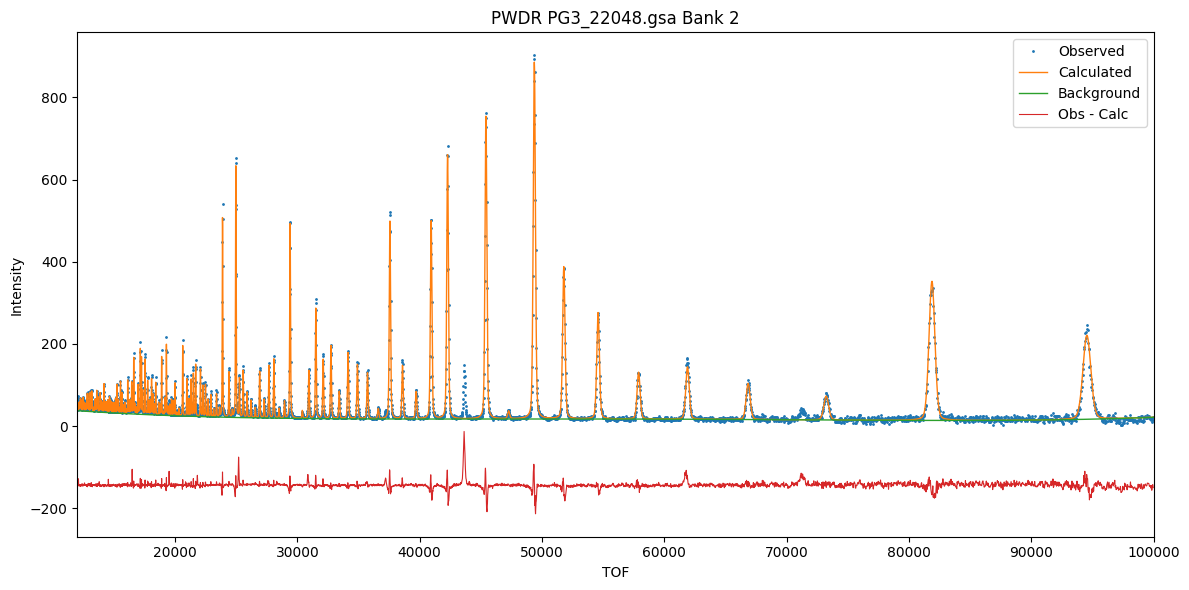

Histogram: PWDR PG3_22048.gsa Bank 2
Limits: [(np.float64(6778.4369582105), np.float64(103793.9994994135)), [12000.0, 100000.0]]
CSV saved: work_tof/tutorial_GSASII/NAC/cycle/profile_difference.csv
PNG saved: work_tof/tutorial_GSASII/NAC/cycle/profile_difference.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== user settings =====
#GSASII_DIR = "/path/to/GSAS-II/GSASII"
#GPX_FILE = "/Users/tsunetomo/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/cycle/final.gpx"
#OUTDIR = Path("/Users/tsunetomo/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/cycle")
#GPX_FILE = "/Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle/final.gpx"
GPX_FILE = "%s/cycle/final.gpx"%(WORKDIR)
#GPX_FILE = "%s/cycle/tof_refine.gpx"%(WORKDIR)
OUTDIR = Path("%s/cycle"%(WORKDIR))
HIST_INDEX = 0
# =========================

gpx = G2sc.G2Project(GPX_FILE)
hist = gpx.histograms()[HIST_INDEX]

x = np.asarray(hist.data["data"][1][0])
yobs = np.asarray(hist.data["data"][1][1])
w = np.asarray(hist.data["data"][1][2])
ycalc = np.asarray(hist.data["data"][1][3])
ybkg = np.asarray(hist.data["data"][1][4])

diff = yobs - ycalc

lo, hi = hist.data["Limits"][1]
mask = (x >= lo) & (x <= hi)

df = pd.DataFrame({
    "x": x[mask],
    "yobs": yobs[mask],
    "ycalc": ycalc[mask],
    "ybkg": ybkg[mask],
    "diff": diff[mask],
    "weight": w[mask],
})

csv_path = OUTDIR / "profile_difference.csv"
png_path = OUTDIR / "profile_difference.png"

df.to_csv(csv_path, index=False)

offset = 1.1 * np.nanmax(np.abs(df["diff"]))

plt.figure(figsize=(12, 6))
plt.plot(df["x"], df["yobs"], ".", markersize=2, label="Observed")
plt.plot(df["x"], df["ycalc"], "-", linewidth=1.0, label="Calculated")
plt.plot(df["x"], df["ybkg"], "-", linewidth=1.0, label="Background")
plt.plot(df["x"], df["diff"] - offset, "-", linewidth=0.8, label="Obs - Calc")

plt.xlim(LIMITS[0], LIMITS[1])

plt.xlabel("TOF")
plt.ylabel("Intensity")
plt.title(hist.name)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=200)
#plt.close()
plt.show()

print("Histogram:", hist.name)
print("Limits:", hist.data["Limits"])
print("CSV saved:", csv_path)
print("PNG saved:", png_path)